# LiDAR: плотность точек → зоны (не depth-маска)

Проецируем `input/lidar.npz` в **камеру сэмпла** (`meta.json` → `camera`, pose @ `target`).

1. **hits** — сколько точек попало в пиксель (+ splat)
2. **density_zone** — Gaussian blur по hits → «зоны» из разреженных точек
3. **lidar_trust** — расширение от hits (**spread**, не blur)

У каждого пикселя trust = f(расстояние до ближайшего hit), без смешивания «чёрной» плотности.
`d1.npy` — только для сравнения.

In [1]:
import json
import re
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REPO = Path(r"C:/Users/adel/Documents/GitHub/YA-")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from lidar_density_mask import build_lidar_density, plot_lidar_density_debug

try:
    import cv2
except ImportError:
    cv2 = None
    raise ImportError("pip install opencv-python")


## 1. CONFIG (пути из consensus_training)

In [2]:
CV_ROOT = Path(r"C:/Users/adel/Downloads/cv_dataset")

@dataclass
class LidarProbeConfig:
    dataset_root: str = str(CV_ROOT / "final_dataset_v5_participants/train")
    baked_root: str = str(CV_ROOT / "rife_refinement_baked/train")
    ego_masks_root: str = str(
        REPO / "methods_gallery/_ego_manual_masks/masks_approved"
    )
    allowed_cameras: tuple = ("front", "rear")
    image_h: int = 544
    image_w: int = 1024
    use_artifact_mask: bool = True
    # LiDAR → зоны
    lidar_timestep: str = "target"
    lidar_splat_radius: int = 2
    lidar_zone_method: str = "spread"   # spread | dilate | gaussian
    lidar_spread_radius_fine: float = 3.0   # px — spread от hit
    lidar_spread_blur_fine: float = 1.0     # σ px blur на fine (0=выкл)
    lidar_spread_radius: float = 14.0       # px — широкая зона
    lidar_spread_falloff: str = "linear"    # linear | hard | cosine
    lidar_zone_min: float = 0.12
    lidar_min_hits_pixel: int = 1
    lidar_preserve_fine: bool = True


CFG = LidarProbeConfig()
TARGET_HW = (CFG.image_h, CFG.image_w)
print("dataset:", CFG.dataset_root)
print("baked:  ", CFG.baked_root)
print("cameras:", CFG.allowed_cameras)
print(f"lidar: {CFG.lidar_zone_method}  splat={CFG.lidar_splat_radius}  "
      f"spread fine={CFG.lidar_spread_radius_fine} blur_f={CFG.lidar_spread_blur_fine} "
      f"zone={CFG.lidar_spread_radius}")


dataset: C:\Users\adel\Downloads\cv_dataset\final_dataset_v5_participants\train
baked:   C:\Users\adel\Downloads\cv_dataset\rife_refinement_baked\train
cameras: ('front', 'rear')
lidar: spread  splat=2  spread fine=3.0 blur_f=1.0 zone=14.0


## 2. Утилиты

In [3]:
VEHICLE_RE = re.compile(r"_([a-zA-Z]+)_\d+__\d{3}$")
EPS = 1e-6


def _parse_vehicle(sample_id: str) -> str | None:
    m = VEHICLE_RE.search(sample_id)
    return m.group(1) if m else None


def _resize_hw(img, target_hw, interp):
    H, W = target_hw
    if img.shape[:2] == (H, W):
        return img
    return cv2.resize(img, (W, H), interpolation=interp)


def _load_ego_mask(cfg, sample_id: str, camera: str, target_hw) -> np.ndarray:
    H, W = target_hw
    if not cfg.use_artifact_mask:
        return np.zeros((H, W), np.float32)
    vehicle = _parse_vehicle(sample_id)
    if not vehicle:
        return np.zeros((H, W), np.float32)
    p = Path(cfg.ego_masks_root) / f"{vehicle}_{camera}.png"
    if not p.is_file():
        return np.zeros((H, W), np.float32)
    m = np.array(Image.open(p).convert("L"))
    return (_resize_hw(m, target_hw, cv2.INTER_NEAREST) > 127).astype(np.float32)


def build_lidar_maps(cfg, sample_dir: Path, camera: str, target_hw=TARGET_HW) -> dict:
    return build_lidar_density(
        sample_dir,
        camera,
        timestep=cfg.lidar_timestep,
        splat_radius=cfg.lidar_splat_radius,
        zone_method=cfg.lidar_zone_method,
        spread_radius_fine=cfg.lidar_spread_radius_fine,
        spread_radius=cfg.lidar_spread_radius,
        spread_falloff=cfg.lidar_spread_falloff,
        spread_blur_fine=cfg.lidar_spread_blur_fine,
        zone_min=cfg.lidar_zone_min,
        min_hits_pixel=cfg.lidar_min_hits_pixel,
        preserve_fine=cfg.lidar_preserve_fine,
        target_hw=target_hw,
    )


def list_baked_samples(cfg, camera: str | None = None) -> list[Path]:
    out = []
    for baked in sorted(Path(cfg.baked_root).iterdir()):
        if not (baked / "meta.json").is_file():
            continue
        meta = json.loads((baked / "meta.json").read_text(encoding="utf-8"))
        cam = meta.get("camera")
        if cfg.allowed_cameras and cam not in cfg.allowed_cameras:
            continue
        if camera and cam != camera:
            continue
        src = Path(meta.get("source_dir", Path(cfg.dataset_root) / meta["sample_id"]))
        if (src / "input" / "lidar.npz").is_file():
            out.append(baked)
    return out


def load_sample_pack(cfg, baked_dir: Path) -> dict:
    """meta + src + lidar maps + rgb + ego + baked depth (для сравнения)."""
    meta = json.loads((baked_dir / "meta.json").read_text(encoding="utf-8"))
    sid, cam = meta["sample_id"], meta["camera"]
    src = Path(meta.get("source_dir", Path(cfg.dataset_root) / sid))
    lm = build_lidar_maps(cfg, src, cam)
    rgb = np.array(Image.open(src / "target" / f"{cam}.jpg").convert("RGB"))
    rgb = _resize_hw(rgb, TARGET_HW, cv2.INTER_LINEAR).astype(np.float32) / 255.0
    art = _load_ego_mask(cfg, sid, cam, TARGET_HW)
    depth_b = None
    dpath = baked_dir / "d1.npy"
    if dpath.is_file():
        depth_b = np.load(dpath).astype(np.float32)
        depth_b = _resize_hw(np.where(np.isfinite(depth_b), depth_b, 0), TARGET_HW, cv2.INTER_NEAREST)
    return dict(meta=meta, src=src, baked=baked_dir, camera=cam, sid=sid, maps=lm, rgb=rgb, art=art, depth_b=depth_b)


BAKED_LIST = list_baked_samples(CFG)
print(f"сэмплов с lidar.npz ({CFG.allowed_cameras}): {len(BAKED_LIST)}")


сэмплов с lidar.npz (('front', 'rear')): 449


## 3. Один сэмпл — hits → зоны → lidar_trust

Поменяй `PROBE_IDX` или задай `PROBE_CAMERA = "front"`.

lidar_trust>0.25: 100.0%


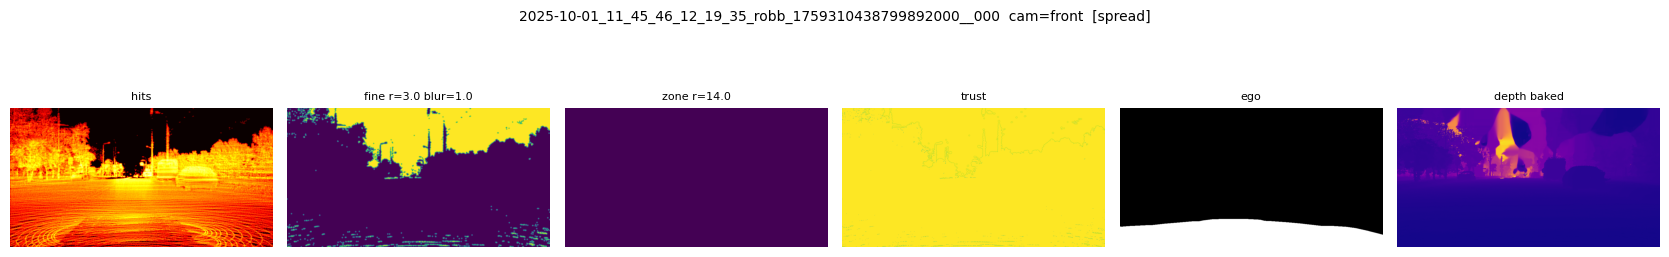

projected: 554240  hits_max=150


In [4]:
PROBE_IDX = 0
PROBE_CAMERA = None  # например "front" — тогда первый front

if PROBE_CAMERA:
    _cands = [b for b in BAKED_LIST if json.loads((b / "meta.json").read_text())["camera"] == PROBE_CAMERA]
    baked = _cands[PROBE_IDX % len(_cands)]
else:
    baked = BAKED_LIST[PROBE_IDX % len(BAKED_LIST)]

pack = load_sample_pack(CFG, baked)
lm, meta, cam = pack["maps"], pack["meta"], pack["camera"]

plot_lidar_density_debug(
    lm, rgb=pack["rgb"], art=pack["art"], depth_baked=pack["depth_b"],
    title=f"{pack['sid']}  cam={cam}",
)
plt.show()
print(f"projected: {lm['n_projected']}  hits_max={lm['hits'].max():.0f}")


## 4. depth + lidar_trust − «дальнее без точек»

Слева depth baked (геометрия), справа маска из **плотности LiDAR**.
Синее = нет зоны лидара (небо / дыры) — там не доверяем depth как маске.

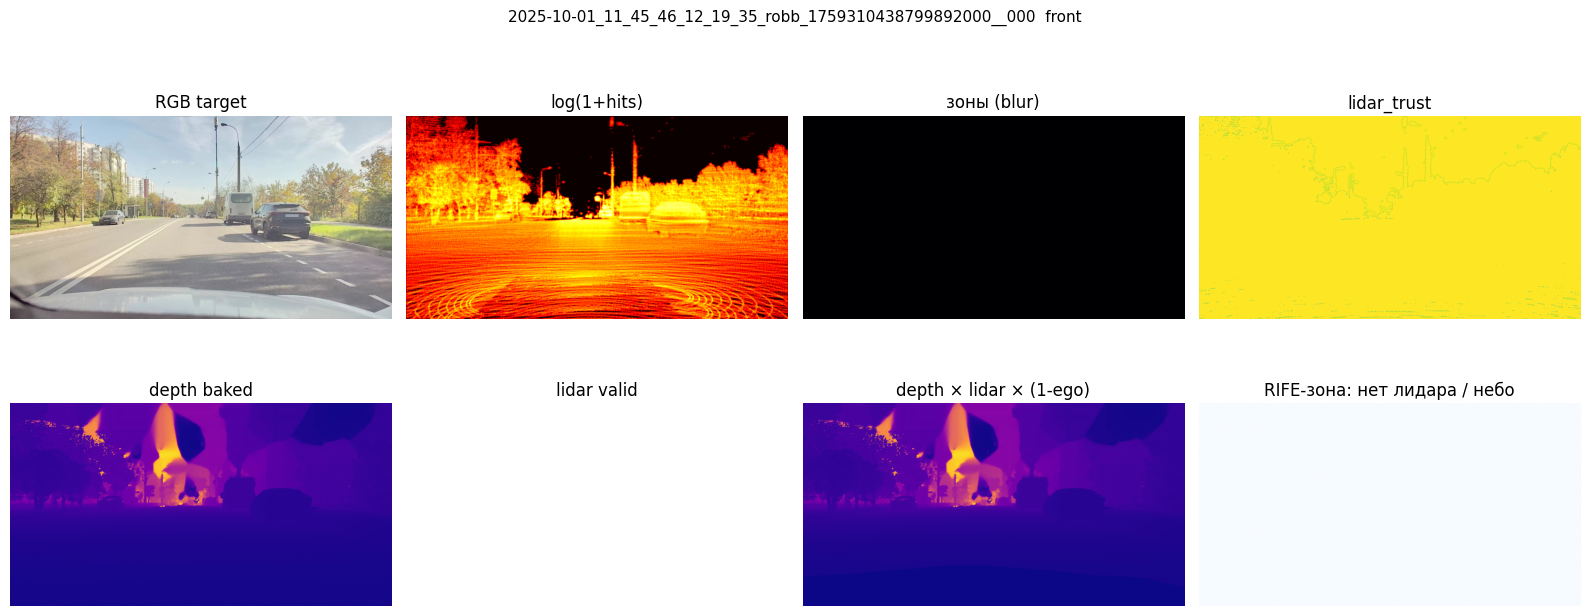

% пикселей: trust_gt_025=100.0, no_lidar=0.0, far_void=0.0, ego=16.6


In [5]:
lm = pack["maps"]
trust = lm["lidar_trust"]
art = pack["art"]
depth_b = pack["depth_b"]

lidar_valid = (trust > 0.05).astype(np.float32)
depth_norm = np.zeros_like(depth_b, np.float32)
if depth_b is not None:
    v = depth_b > 0
    if v.any():
        depth_norm[v] = depth_b[v] / (depth_b[v].max() + EPS)

scene_lidar = depth_norm * lidar_valid * (1.0 - art)
no_lidar = 1.0 - lidar_valid
far_void = no_lidar * (depth_norm < 0.02)  # небо: depth≈0 и нет точек

fig, ax = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(f"{pack['sid']}  {cam}", fontsize=11)

ax[0, 0].imshow(pack["rgb"]); ax[0, 0].set_title("RGB target")
ax[0, 1].imshow(np.log1p(lm["hits"]), cmap="hot"); ax[0, 1].set_title("log(1+hits)")
ax[0, 2].imshow(lm["density_zone"] / (lm["density_zone"].max() + EPS), cmap="inferno")
ax[0, 2].set_title("зоны (blur)")
ax[0, 3].imshow(trust, cmap="viridis", vmin=0, vmax=1); ax[0, 3].set_title("lidar_trust")

ax[1, 0].imshow(depth_norm, cmap="plasma", vmin=0, vmax=1); ax[1, 0].set_title("depth baked")
ax[1, 1].imshow(lidar_valid, cmap="gray", vmin=0, vmax=1); ax[1, 1].set_title("lidar valid")
ax[1, 2].imshow(scene_lidar, cmap="plasma", vmin=0, vmax=1); ax[1, 2].set_title("depth × lidar × (1-ego)")
ax[1, 3].imshow(np.maximum(no_lidar, far_void), cmap="Blues", vmin=0, vmax=1)
ax[1, 3].set_title("RIFE-зона: нет лидара / небо")

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

pct = dict(
    trust_gt_025=100 * (trust > 0.25).mean(),
    no_lidar=100 * no_lidar.mean(),
    far_void=100 * far_void.mean(),
    ego=100 * art.mean(),
)
print("% пикселей:", ", ".join(f"{k}={v:.1f}" for k, v in pct.items()))


## 5. Подбор spread_radius / splat (на том же сэмпле)

Сравни **spread** (градиент от hit) vs старый **gaussian**.

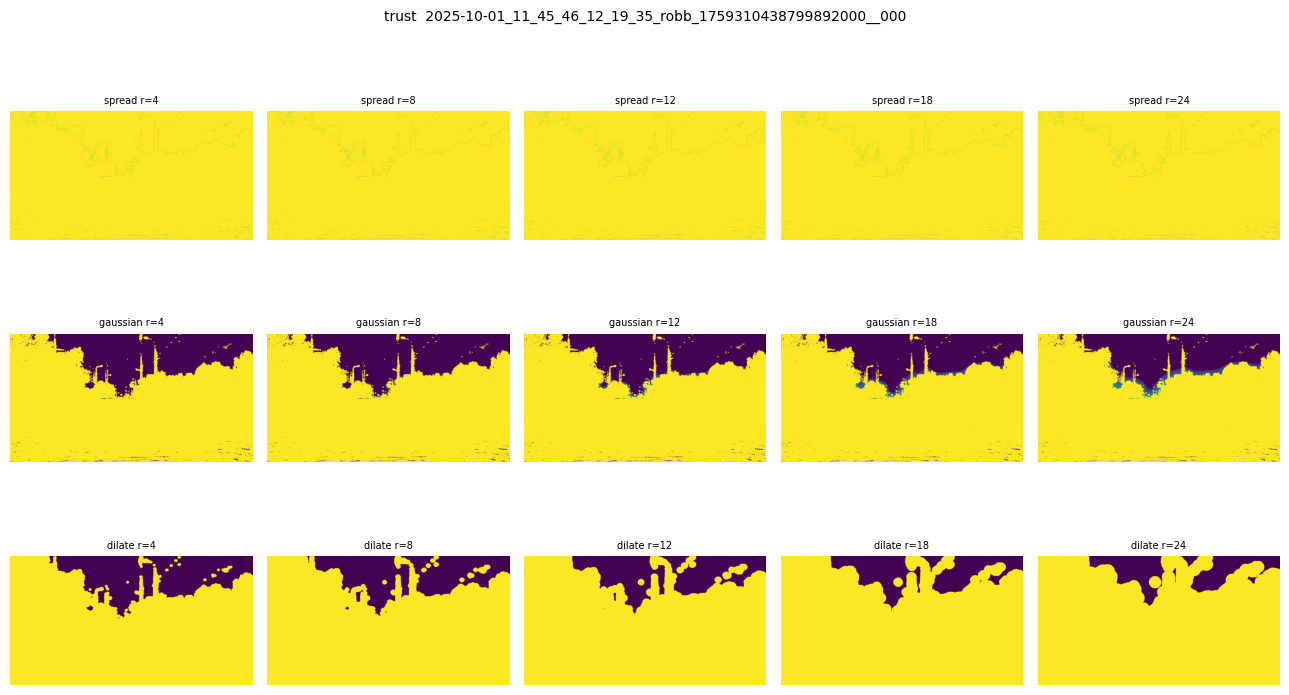

In [6]:
src, cam = pack["src"], pack["camera"]
radii = [4, 8, 12, 18, 24]
methods = ["spread", "gaussian", "dilate"]

fig, axes = plt.subplots(len(methods), len(radii), figsize=(2.6 * len(radii), 2.6 * len(methods)))
fig.suptitle(f"trust  {pack['sid']}", fontsize=10)
for i, meth in enumerate(methods):
    for j, r in enumerate(radii):
        kw = dict(
            splat_radius=CFG.lidar_splat_radius, zone_method=meth,
            spread_radius_fine=CFG.lidar_spread_radius_fine,
            spread_radius=r, zone_min=CFG.lidar_zone_min, target_hw=TARGET_HW,
        )
        if meth == "gaussian":
            kw["zone_sigma"] = r
            kw["zone_sigma_fine"] = CFG.lidar_spread_radius_fine
        m = build_lidar_density(src, cam, **kw)
        axes[i, j].imshow(m["lidar_trust"], cmap="viridis", vmin=0, vmax=1)
        axes[i, j].set_title(f"{meth} r={r}", fontsize=7)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()


## 6. Несколько сэмплов (front / rear)

Быстрый просмотр 6 примеров.

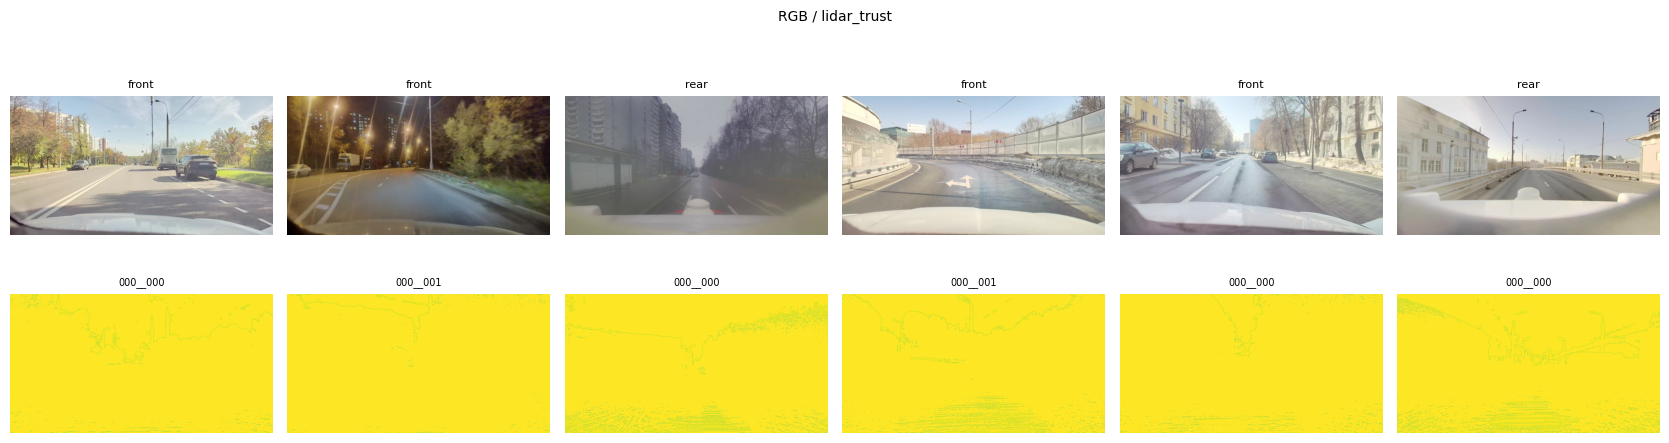

In [7]:
N_SHOW = 6
step = max(1, len(BAKED_LIST) // N_SHOW)
fig, axes = plt.subplots(2, N_SHOW, figsize=(2.8 * N_SHOW, 5))
for col, bi in enumerate(range(0, len(BAKED_LIST), step)[:N_SHOW]):
    p = load_sample_pack(CFG, BAKED_LIST[bi])
    t = p["maps"]["lidar_trust"]
    axes[0, col].imshow(p["rgb"])
    axes[0, col].set_title(p["camera"], fontsize=8)
    axes[1, col].imshow(t, cmap="viridis", vmin=0, vmax=1)
    axes[1, col].set_title(p["sid"][-8:], fontsize=7)
    for r in range(2):
        axes[r, col].axis("off")
plt.suptitle("RGB / lidar_trust", fontsize=10)
plt.tight_layout()
plt.show()
